N = 100, M = 2000 mẫu, burn-in = 200 vòng
E[#số 1] ước lượng : 27.6975
E[#số 1] lý thuyết : 33.6667
Sai số chuẩn (SE)  : 0.0679
CI 95%             : [27.5645, 27.8305]
Tỉ lệ số 1         : 27.7%


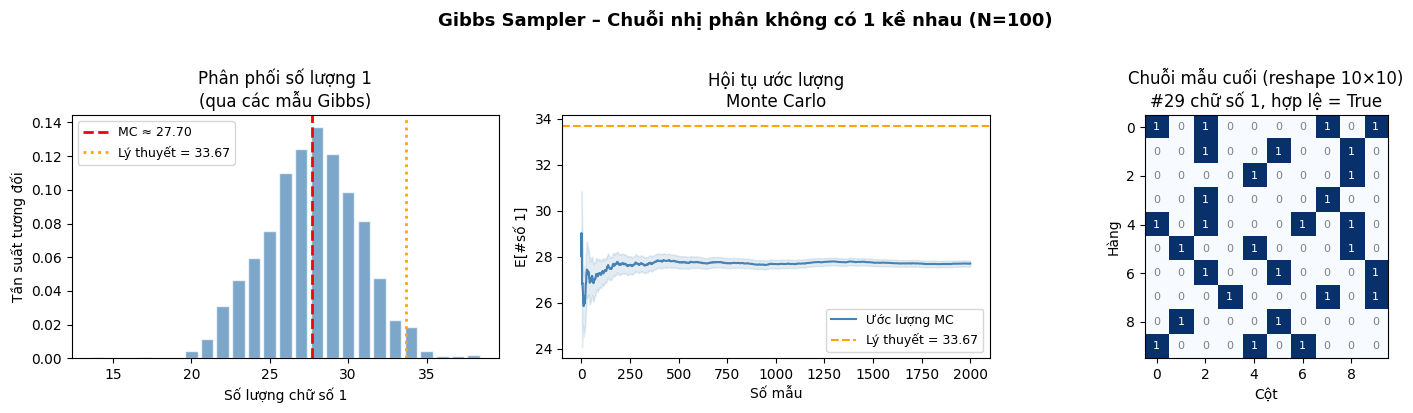

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ============================================================
# CƠ SỞ LÝ THUYẾT
# Không gian S = tất cả chuỗi nhị phân độ dài N không có 2 chữ số 1 kề nhau
# Phân phối mục tiêu: π đồng đều trên S
# Gibbs Sampler: tại mỗi bước, chọn ngẫu nhiên 1 vị trí i,
#   cập nhật x_i theo phân phối điều kiện đầy đủ p(x_i | x_{-i})
#   Nếu x_{i-1}=1 hoặc x_{i+1}=1 → x_i phải = 0 (xác suất 1)
#   Ngược lại → x_i = 0 hoặc 1 với xác suất bằng nhau (1/2)
# ============================================================

np.random.seed(42)
N = 100       # độ dài chuỗi
M = 2000      # số mẫu Monte Carlo
BURN_IN = 200 # số vòng burn-in (mỗi vòng = N bước Gibbs)

# --- Khởi tạo chuỗi hợp lệ ---
def init_chain(N):
    x = np.zeros(N, dtype=int)
    x[::2] = 1  # đặt 1 ở các vị trí chẵn: 1,0,1,0,...
    return x

# --- Một bước Gibbs ---
def gibbs_step(x):
    N = len(x)
    i = np.random.randint(N)
    # Kiểm tra hàng xóm
    left_is_one  = (i > 0)   and (x[i-1] == 1)
    right_is_one = (i < N-1) and (x[i+1] == 1)
    if left_is_one or right_is_one:
        x[i] = 0  # bắt buộc = 0 để giữ tính hợp lệ
    else:
        x[i] = np.random.randint(2)  # tự do chọn 0 hoặc 1
    return x

# --- Kiểm tra chuỗi hợp lệ ---
def is_valid(x):
    return not any(x[i] == 1 and x[i+1] == 1 for i in range(len(x)-1))

# --- Chạy Gibbs Sampler ---
x = init_chain(N)

# Burn-in: cho chuỗi "quên" trạng thái khởi tạo
for _ in range(BURN_IN * N):
    gibbs_step(x)

# Thu thập mẫu
samples = []
for m in range(M):
    for _ in range(N):  # N bước Gibbs = 1 "sweep"
        gibbs_step(x)
    assert is_valid(x), f"Lỗi: chuỗi không hợp lệ ở mẫu {m}"
    samples.append(x.sum())

samples = np.array(samples)

# --- Ước lượng Monte Carlo ---
E_hat   = samples.mean()
SE      = samples.std() / np.sqrt(M)
CI_low  = E_hat - 1.96 * SE
CI_high = E_hat + 1.96 * SE

# --- Giá trị lý thuyết ---
# Số chuỗi độ dài N hợp lệ = F(N+2) (số Fibonacci)
# E[X] = (N+1)/3  (có thể chứng minh bằng đệ quy)
E_theory = (N + 1) / 3

print("=" * 50)
print(f"N = {N}, M = {M} mẫu, burn-in = {BURN_IN} vòng")
print(f"E[#số 1] ước lượng : {E_hat:.4f}")
print(f"E[#số 1] lý thuyết : {E_theory:.4f}")
print(f"Sai số chuẩn (SE)  : {SE:.4f}")
print(f"CI 95%             : [{CI_low:.4f}, {CI_high:.4f}]")
print(f"Tỉ lệ số 1         : {E_hat/N*100:.1f}%")
print("=" * 50)

# --- Trực quan hóa ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Histogram phân phối số 1
ax = axes[0]
freq = Counter(samples)
keys = sorted(freq.keys())
vals = [freq[k]/M for k in keys]
ax.bar(keys, vals, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(E_hat,    color='red',   lw=2, ls='--', label=f'MC ≈ {E_hat:.2f}')
ax.axvline(E_theory, color='orange',lw=2, ls=':',  label=f'Lý thuyết = {E_theory:.2f}')
ax.set_xlabel('Số lượng chữ số 1')
ax.set_ylabel('Tần suất tương đối')
ax.set_title('Phân phối số lượng 1\n(qua các mẫu Gibbs)')
ax.legend(fontsize=9)

# 2. Hội tụ của ước lượng
ax = axes[1]
run_means = np.cumsum(samples) / np.arange(1, M+1)
ax.plot(run_means, color='steelblue', lw=1.5, label='Ước lượng MC')
ax.axhline(E_theory, color='orange', lw=1.5, ls='--', label=f'Lý thuyết = {E_theory:.2f}')
ax.fill_between(range(M),
                run_means - 1.96*np.array([samples[:i+1].std()/np.sqrt(i+1) for i in range(M)]),
                run_means + 1.96*np.array([samples[:i+1].std()/np.sqrt(i+1) for i in range(M)]),
                alpha=0.15, color='steelblue')
ax.set_xlabel('Số mẫu')
ax.set_ylabel('E[#số 1]')
ax.set_title('Hội tụ ước lượng\nMonte Carlo')
ax.legend(fontsize=9)

# 3. Hiển thị một chuỗi mẫu
ax = axes[2]
ax.imshow(x.reshape(10, 10), cmap='Blues', vmin=0, vmax=1,
          aspect='equal', interpolation='nearest')
ax.set_title(f'Chuỗi mẫu cuối (reshape 10×10)\n#{x.sum()} chữ số 1, hợp lệ = {is_valid(x)}')
ax.set_xlabel('Cột'); ax.set_ylabel('Hàng')
for i in range(10):
    for j in range(10):
        ax.text(j, i, str(x[i*10+j]),
                ha='center', va='center', fontsize=8,
                color='white' if x[i*10+j]==1 else 'gray')

plt.suptitle(f'Gibbs Sampler – Chuỗi nhị phân không có 1 kề nhau (N={N})',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gibbs_binary_chain.png', dpi=150, bbox_inches='tight')
plt.show()